# Exploratory Data Analysis – Laptop Pricing Dataset

## Overview
This notebook explores which laptop features have the strongest relationship with price.

## Objectives
In this lab, I will:
- visualize individual feature patterns
- run descriptive statistical analysis
- use groupby and pivot tables
- calculate Pearson correlation coefficients and p-values

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline

## Load Dataset

Load the updated laptop pricing dataset from the provided URL.

In [11]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

df = pd.read_csv(url, header=0)
df.drop(["Unnamed: 0", "Unnamed: 0.1"], axis=1, inplace=True)

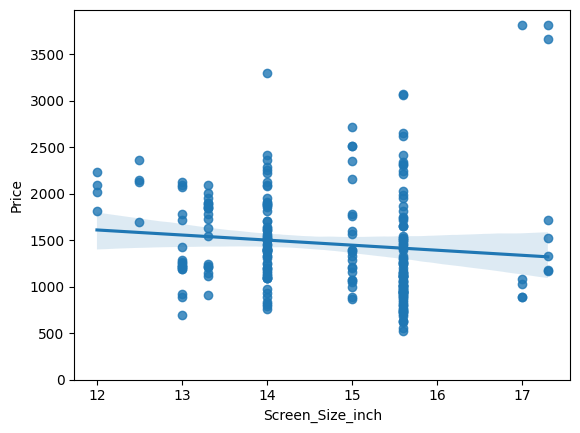

In [12]:
sns.regplot(x="Screen_Size_inch", y="Price", data=df)
plt.ylim(0,)
plt.show()

In [13]:
df[["Screen_Size_inch", "Price"]].corr()

,Screen_Size_inch,Price
Screen_Size_inch,1.000000,-0.110644
Price,-0.110644,1.000000


## Initial Data Check

First, I inspect the structure of the dataset.

In [3]:
df.dtypes

,0
Unnamed: 0.1,int64
Unnamed: 0,int64
Manufacturer,object
Category,int64
GPU,int64
OS,int64
CPU_core,int64
Screen_Size_inch,float64
CPU_frequency,float64
RAM_GB,int64


## Task 1: Visualize Individual Feature Patterns

### Continuous Variables

I will create regression plots for:
- `CPU_frequency`
- `Screen_Size_cm`
- `Weight_pounds`

Then I will check the correlation of each feature with `Price`.

In [4]:
#### CPU Frequency vs Price

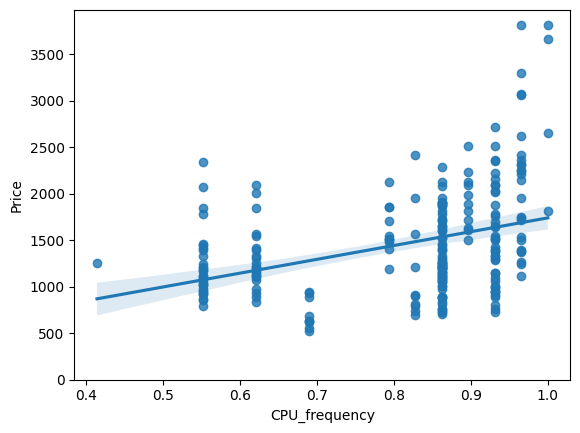

In [5]:
sns.regplot(x="CPU_frequency", y="Price", data=df)
plt.ylim(0,)
plt.show()

In [6]:
df[["CPU_frequency", "Price"]].corr()

,CPU_frequency,Price
CPU_frequency,1.000000,0.366666
Price,0.366666,1.000000


#### Screen Size vs Price

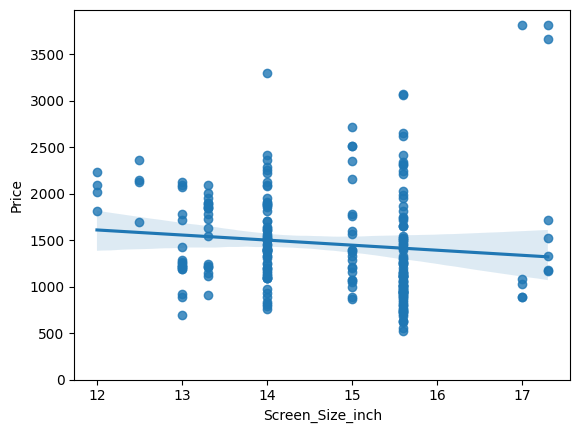

In [9]:
sns.regplot(x="Screen_Size_inch", y="Price", data=df)
plt.ylim(0,)
plt.show()

#### Weight (Pounds) vs Price

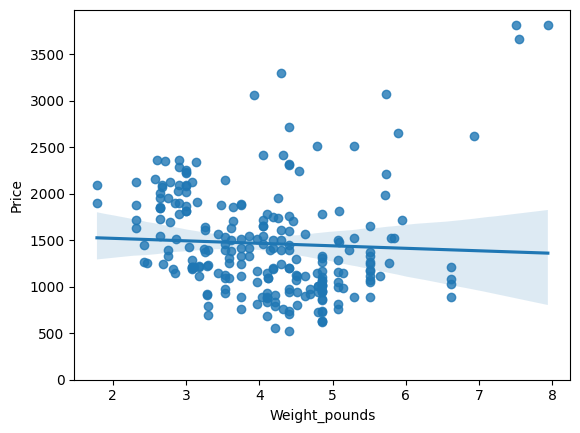

In [14]:
sns.regplot(x="Weight_pounds", y="Price", data=df)
plt.ylim(0,)
plt.show()

In [15]:
df[["Weight_pounds", "Price"]].corr()

,Weight_pounds,Price
Weight_pounds,1.000000,-0.050312
Price,-0.050312,1.000000


### Categorical Features

Now I create box plots for the categorical features to compare how price varies across categories.

#### Category vs Price

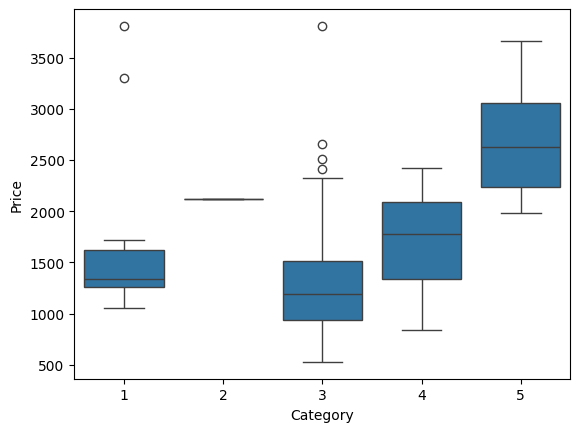

In [16]:
sns.boxplot(x="Category", y="Price", data=df)
plt.show()

#### GPU vs Price

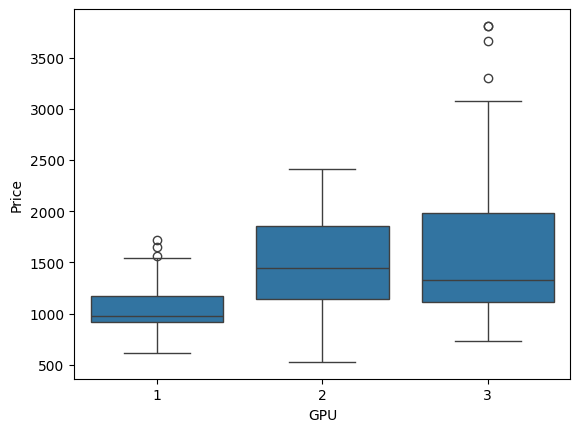

In [17]:
sns.boxplot(x="GPU", y="Price", data=df)
plt.show()

#### OS vs Price

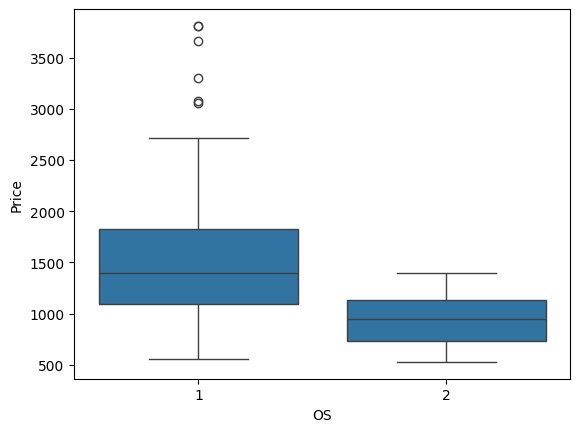

In [18]:
sns.boxplot(x="OS", y="Price", data=df)
plt.show()

#### CPU Core vs Price

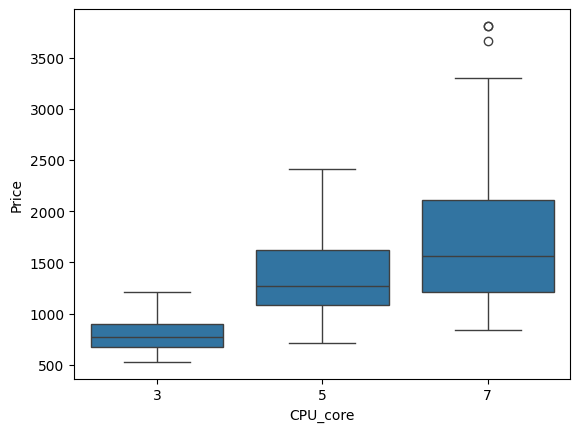

In [19]:
sns.boxplot(x="CPU_core", y="Price", data=df)
plt.show()

#### RAM vs Price

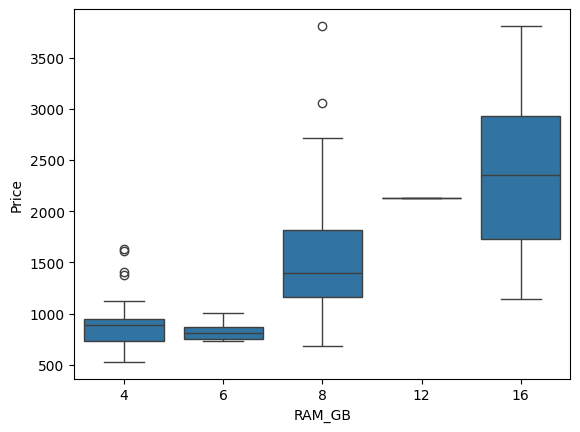

In [20]:
sns.boxplot(x="RAM_GB", y="Price", data=df)
plt.show()

#### Storage vs Price

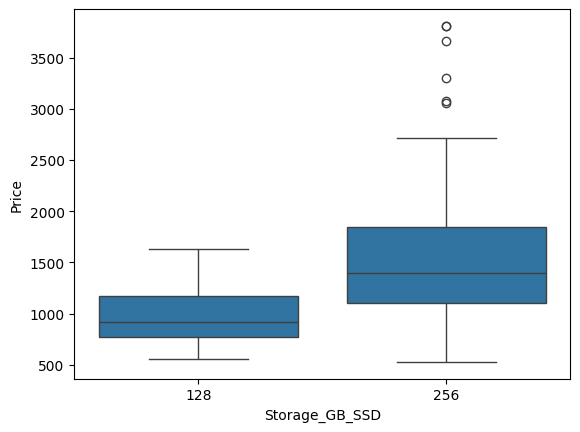

In [21]:
sns.boxplot(x="Storage_GB_SSD", y="Price", data=df)
plt.show()

## Task 2: Descriptive Statistical Analysis

Now I generate descriptive statistics for the full dataset, including object-type columns.

In [22]:
df.describe(include="all")

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
count,238,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238,238.000000,238.000000
unique,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN
top,Dell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN
freq,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,160,NaN,NaN
mean,NaN,3.205882,2.151261,1.058824,5.630252,14.688655,0.813822,7.882353,245.781513,4.106221,1462.344538,NaN,0.676471,0.323529
std,NaN,0.776533,0.638282,0.235790,1.241787,1.166045,0.141860,2.482603,34.765316,1.078442,574.607699,NaN,0.468809,0.468809
min,NaN,1.000000,1.000000,1.000000,3.000000,12.000000,0.413793,4.000000,128.000000,1.786050,527.000000,NaN,0.000000,0.000000
25%,NaN,3.000000,2.000000,1.000000,5.000000,14.000000,0.689655,8.000000,256.000000,3.246863,1066.500000,NaN,0.000000,0.000000
50%,NaN,3.000000,2.000000,1.000000,5.000000,15.000000,0.862069,8.000000,256.000000,4.106221,1333.000000,NaN,1.000000,0.000000
75%,NaN,4.000000,3.000000,1.000000,7.000000,15.600000,0.931034,8.000000,256.000000,4.851000,1777.000000,NaN,1.000000,1.000000


## Task 3: GroupBy and Pivot Tables

### Group by GPU and CPU Core

Here, I calculate the average price for each combination of GPU and CPU core count.

In [23]:
grouped_test = df[["GPU", "CPU_core", "Price"]].groupby(
    ["GPU", "CPU_core"], as_index=False
)["Price"].mean()

grouped_test

,GPU,CPU_core,Price
0,1,3,769.250000
1,1,5,998.500000
2,1,7,1167.941176
3,2,3,785.076923
4,2,5,1462.197674
5,2,7,1744.621622
6,3,3,784.000000
7,3,5,1220.680000
8,3,7,1945.097561


### Create Pivot Table

Now I reshape the grouped results into a pivot table for easier comparison.

In [24]:
grouped_pivot = grouped_test.pivot(index="GPU", columns="CPU_core")
grouped_pivot

Price                          
CPU_core           3            5            7
GPU                                           
1         769.250000   998.500000  1167.941176
2         785.076923  1462.197674  1744.621622
3         784.000000  1220.680000  1945.097561

### Fill Missing Values

Some category combinations may not exist in the dataset, so I replace missing values with 0.

In [25]:
grouped_pivot = grouped_pivot.fillna(0)
grouped_pivot

Price                          
CPU_core           3            5            7
GPU                                           
1         769.250000   998.500000  1167.941176
2         785.076923  1462.197674  1744.621622
3         784.000000  1220.680000  1945.097561

### Visualize Pivot Table

This color plot helps show how price varies across combinations of GPU and CPU core values.

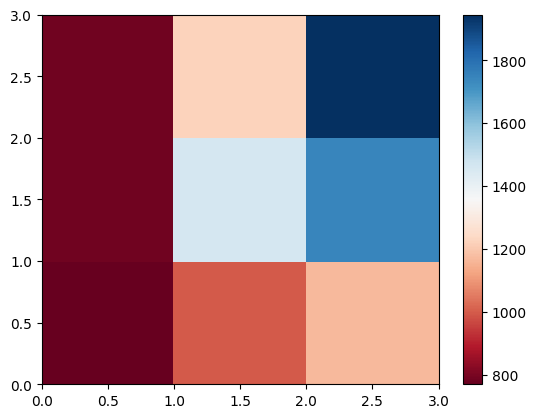

In [26]:
plt.pcolor(grouped_pivot, cmap="RdBu")
plt.colorbar()
plt.show()

### Improved Labels for Pivot Table Plot

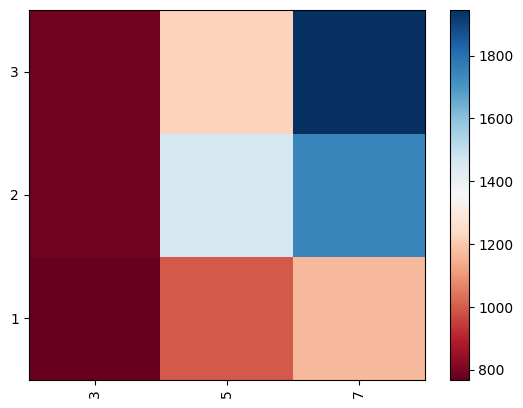

In [35]:
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap="RdBu")

row_labels = grouped_pivot.index
col_labels = grouped_pivot.columns.get_level_values(1)

ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

ax.set_xticklabels(col_labels, minor=False)
ax.set_yticklabels(row_labels, minor=False)

plt.xticks(rotation=90)
fig.colorbar(im)
plt.show()

In [28]:
col_labels = grouped_pivot.columns.get_level_values(1)

## Task 4: Pearson Correlation and p-values

Now I use Pearson correlation and p-values to evaluate how strongly each continuous feature is related to price.

### CPU Frequency vs Price

In [31]:
pearson_coef, p_value = stats.pearsonr(df["CPU_frequency"], df["Price"])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)

The Pearson Correlation Coefficient is 0.36666555892588604  with a P-value of P = 5.502463350713357e-09


### Screen Size vs Price

In [33]:
pearson_coef, p_value = stats.pearsonr(df["Screen_Size_inch"], df["Price"])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)

The Pearson Correlation Coefficient is -0.11064420817118266  with a P-value of P = 0.08853397846830661


### Weight (Pounds) vs Price

In [34]:
pearson_coef, p_value = stats.pearsonr(df["Weight_pounds"], df["Price"])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)

The Pearson Correlation Coefficient is -0.05031225837751549  with a P-value of P = 0.4397693853433896


## Conclusion

Based on the visualizations, grouped analysis, and Pearson correlation tests:

- `CPU_frequency` shows the strongest positive relationship with price
- `Screen_Size_inch` and `Weight_pounds` show weaker relationships with price
- categorical features such as `Category`, `GPU`, and `CPU_core` also affect price patterns

## Key Takeaways

- Visualizations help reveal both strong and weak relationships with price
- GroupBy and pivot tables make category comparisons easier
- Pearson correlation and p-values help confirm statistical relationships